# Faster code II

As a more realistic example of speeding up your code, I took the liberty of playing around with Ramos' code for plotting Wigner functions of Gaussian states, that is, calculating the function values on a grid of x and p values.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [21]:
# Wigner calc method from Ramos

class GaussianState:
    def __init__(self, mean: NDArray[np.float64], cov: NDArray[np.float64]):
        self.name = "Gaussian State" 
        self.mean = mean
        self.cov = cov

    def __repr__(self):
        mean_str = np.array2string(self.mean, precision=3, suppress_small=True)
        cov_str = np.array2string(self.cov, precision=3, suppress_small=True)
        cov_str_indented = '\n'.join('    ' + line for line in cov_str.splitlines())

        return (
            f"GaussianState(\n"
            f"  mean (shape {self.mean.shape}): {mean_str},\n"
            f"  cov (shape {self.cov.shape}):\n{cov_str_indented}\n)"
        )

def wigner(state: GaussianState, r: NDArray[np.float64]):

    den = 2 * np.pi * np.sqrt(np.linalg.det(state.cov))

    exp = -0.5 * (r - state.mean).T @ np.linalg.inv(state.cov) @ (r - state.mean)

    return 1/den * np.exp(exp)


def build_wigner(state, grid_points=100):
    x = np.linspace(-5, 5, grid_points)
    X, P = np.meshgrid(x, x)
    
    W = np.empty_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            r = np.array([X[i, j], P[i, j]])
            W[i, j] = wigner(state, r)

    return X, P, W

In [22]:
state = GaussianState(np.array([2.,-2.]),np.array([[1,0.5],[0.5,1],]))

In [23]:
X, P, W = build_wigner(state, 100)

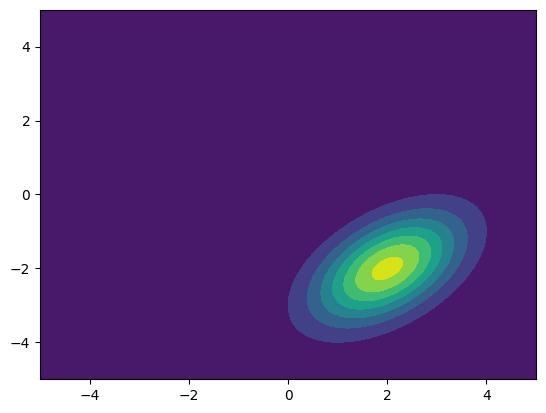

In [24]:
plt.contourf(X, P, W)

In [25]:
%timeit build_wigner(state, 100)

166 ms ± 1.72 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Faster!

In [26]:
Wref = build_wigner(state, 100)[2]

In [28]:
%lprun -f build_wigner -f wigner build_wigner(state, 100)

Timer unit: 1e-09 s

Total time: 0.695712 s
File: /tmp/ipykernel_36589/2952211918.py
Function: wigner at line 20

Line #      Hits         Time  Per Hit   % Time  Line Contents
    20                                           def wigner(state: GaussianState, r: NDArray[np.float64]):
    21                                           
    22     10000  243621845.0  24362.2     35.0      den = 2 * np.pi * np.sqrt(np.linalg.det(state.cov))
    23                                           
    24     10000  430653130.0  43065.3     61.9      exp = -0.5 * (r - state.mean).T @ np.linalg.inv(state.cov) @ (r - state.mean)
    25                                           
    26     10000   21437142.0   2143.7      3.1      return 1/den * np.exp(exp)

Total time: 0.745499 s
File: /tmp/ipykernel_36589/2952211918.py
Function: build_wigner at line 29

Line #      Hits         Time  Per Hit   % Time  Line Contents
    29                                           def build_wigner(state, grid_points=10

What makes this very heavy is the 10000 calls to `wigner` (from the 100×100 loop) which – each time – calculates the determinant and inverse of the covariance matrix, although this matrix doesn't change across function calls.

Before addressing that, let's just see if Numba can do something for us easily (Numba can significantly speed up loops):

In [35]:
@njit
def wigner_numba(state: GaussianState, r: NDArray[np.float64]):

    den = 2 * np.pi * np.sqrt(np.linalg.det(state.cov))

    exp = -0.5 * (r - state.mean).T @ np.linalg.inv(state.cov) @ (r - state.mean)

    return 1/den * np.exp(exp)

@njit
def build_wigner_numba(state, grid_points=100):
    x = np.linspace(-5, 5, grid_points)
    X, P = np.meshgrid(x, x)
    
    W = np.empty_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            r = np.array([X[i, j], P[i, j]])
            W[i, j] = wigner_numba(state, r)

    return X, P, W

In [36]:
%timeit build_wigner_numba(state, 100)

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
non-precise type pyobject
During: typing of argument at /tmp/ipykernel_36589/2530381804.py (10)

File "../../../../tmp/ipykernel_36589/2530381804.py", line 10:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference 

This error may have been caused by the following argument(s):
- argument 0: Cannot determine Numba type of <class '__main__.GaussianState'>


Doesn't work out of the box, but changing the code a bit makes it work. I pass the covariance matrix and mean vector directly as arguments instead of the custom `GaussianState` class that Numba doesn't like. Also had to get rid of `meshgrid`:

In [37]:
@njit
def wigner_numba(cov: NDArray[np.float64], mean: NDArray[np.float64], r: NDArray[np.float64]):

    den = 2 * np.pi * np.sqrt(np.linalg.det(cov))

    exp = -0.5 * (r - mean).T @ np.linalg.inv(cov) @ (r - mean)

    return 1/den * np.exp(exp)



@njit
def build_wigner_numba(cov, mean, grid_points=100):
    x = np.linspace(-5, 5, grid_points)
    # X, P = np.meshgrid(x, x)  # not supported by Numba
    
    W = np.empty_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            # r = np.array([X[i, j], P[i, j]])
            W[i, j] = wigner_numba(cov, mean, np.array([x[i], x[j]]))

    return W

In [38]:
%timeit build_wigner_numba(state.cov, state.mean, 100)

8.75 ms ± 388 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


Nice! More than 20 times faster.

Now let's calculate the determinant and inverse matrix only once. I calculate it in `build_wigner_numba` and pass it as arguments to `wigner_numba`. Ugly code, but it gets the job done, and there's another ~×4 speed-up:

In [40]:
@njit
def wigner_numba(cov: NDArray[np.float64], mean: NDArray[np.float64], r: NDArray[np.float64], covdet: NDArray[np.float64]=None, covinv: NDArray[np.float64]=None):
    if covdet is not None:
        den = 2 * np.pi * np.sqrt(covdet)
    else:
        den = 2 * np.pi * np.sqrt(np.linalg.det(cov))
    
    if covinv is not None:
        exp = -0.5 * (r - mean).T @ covinv @ (r - mean)
    else:
        exp = -0.5 * (r - mean).T @ np.linalg.inv(cov) @ (r - mean)

    return 1/den * np.exp(exp)



@njit
def build_wigner_numba(cov, mean, grid_points=100):
    x = np.linspace(-5, 5, grid_points)

    covdet = np.linalg.det(cov)
    covinv = np.linalg.inv(cov)
    
    W = np.empty_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            # r = np.array([X[i, j], P[i, j]])
            W[j, i] = wigner_numba(cov, mean, np.array([x[i], x[j]]), covdet, covinv)  # transposed (W[j, i]) because no meshgrid

    return W

In [41]:
%timeit build_wigner_numba(state.cov, state.mean, 100)

2.37 ms ± 194 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [42]:
np.allclose(Wref, build_wigner_numba(state.cov, state.mean, 100))

True

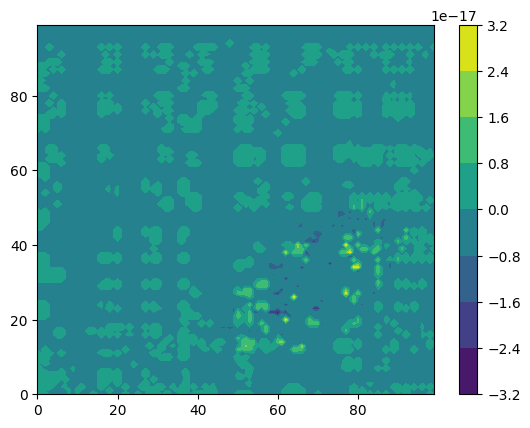

In [43]:
plt.contourf(Wref - build_wigner_numba(state.cov, state.mean, 100))
plt.colorbar()

I tried to use JAX, but didn't get very far. Future work!

In [48]:
from functools import partial

@jaxjit
def wigner_jax(cov: NDArray[np.float64], mean: NDArray[np.float64], rx: np.float64, rp: np.float64):

    den = 2 * np.pi * jnp.sqrt(jnp.linalg.det(cov))

    exp = -0.5 * (r - mean).T @ jnp.linalg.inv(cov) @ (r - mean)

    return 1/den * jnp.exp(exp)

@partial(jaxjit, static_argnums=2)
def build_wigner_jax(cov, mean, grid_points=100):
    x = jnp.linspace(-5, 5, grid_points)
    X, P = jnp.meshgrid(x, x)
    
    W = jnp.empty_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            # r = np.array([X[i, j], P[i, j]])
            W.at[i, j].set(wigner_jax(cov, mean, x[i], x[j]))

    return W

In [49]:
np.allclose(Wref, build_wigner_jax(state.cov, state.mean, 100))

NameError: name 'r' is not defined

In [50]:
build_wigner_jax(state, 100)

TypeError: Error interpreting argument to <function build_wigner_jax at 0x7abc206b2840> as an abstract array. The problematic value is of type <class '__main__.GaussianState'> and was passed to the function at path cov.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

#### Rewriting

Rather than using Numba, JAX or similar, we can actually get a massive speed-up simply by rewriting the code to pass the entire meshgrid to `wigner`, which is therefore run just once, and use `einsum` for its matrix multiplication: 

In [51]:
def wigner2(state: GaussianState, r: NDArray[np.float64]):

    den = 2 * np.pi * np.sqrt(np.linalg.det(state.cov))

    # exp = -0.5 * (r - state.mean).T @ np.linalg.inv(state.cov) @ (r - state.mean)

    exp = -.5 * np.einsum('...j,jk,...k', r - state.mean, np.linalg.inv(state.cov), r - state.mean)

    return 1/den * np.exp(exp)


def build_wigner2(state, grid_points=100):
    x = np.linspace(-5, 5, grid_points)
    X, P = np.meshgrid(x, x)

    W = wigner2(state, np.stack((X,P), -1)) 
    # W = np.empty_like(X)
    # for i in range(grid_points):
    #     for j in range(grid_points):
    #         r = np.array([X[i, j], P[i, j]])
    #         W[i, j] = wigner(state, r)

    return W

In [52]:
%timeit build_wigner2(state, 100)

534 μs ± 23.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [53]:
np.allclose(build_wigner2(state, 100), Wref)

True